# Bayesian model outline

So each questions has a forest of skillIds. Now we can build out this like a skills tree. What that means is we have to figure out how to update abilities of the tree. I think i good method is by only dealing with no

## Definitions
A rooted subtree is a tree that is a subgraph of a rooted tree $T$, shares the **same root node**, and contains a **subset** of the **vertices (and edges)**.

$$\text{Math Ability} \sim N(0,1)$$
$$\text{Science Ability} \sim N(0,1)$$
$$\text{Question Difficulty} \sim N(0,1)$$
Note all of these can have hyper parameters for the group!

Now each question has a tree / forest (exactly two trees) for the abilities. The collection of verticies for the tags of the questions form two trees: a science tree and a math tree. Then on each of these a question has a subtree (some questions only have a math subtree so the other subtree is of size and magnitude 0).

For each tag we have something called a level. I believe this describes the depth of the node in the tree rather than the explicity difficulty. Note that as things go deeper into the tree they tend to be more difficult.

So now how are we going to take a tree structure and update it??? 
My idea is simple but crazy. We take as a prior for each level the devision of the level above it. So if my math ability is 0 then my prior for the subabilites would be that split by the children of that node. So if maths only had three childern BIDMAS; Algebra;Geometry and Measure: Then we would divide this by the prior.



So 
$$\text{Math Ability} = \text{BIDMAS Ability} +  \text{Algebra Ability} + \text{Geometry and Measure Ability}$$
Then when we update the abilities we only focus on updating the leaves of the problem and then can propaget it back through so most nodes and then we propagate the change through. So we get dristibutions for the base children then update that for the parents as the sum of them.

> **Extra complextity**
> It may be reasonable to assume that we must have not actually have an equal splitting and that we can have a proportionality distribution at each parent node that the population shares.




The actual model. What do we have we have an ability at each of the leaf nodes and the difficulty of the problem.
One slight thing of importance is that when a problem uses many different parts of math it can contradictorly become easier. Also note there is often an elimination process involved in multiple choice to make it better our ratings of peoples abilities better.

Call each of the leaf node abilites $l_i$ then these will all follow a normal. So now if we have this ability we can say. Note the $Q$ our question so order does not matter of skills so we just refer to our question as being the set of our leaf node abilities (and a difficulty parameter...)
$$l_i \sim N(0,1)$$
$$Q \subseteq \{l_i,l_j,l_k\} $$
$$p = \text {logistic}(l_i+l_j+l_k-D)$$
$$C \sim \text{Bern}(p)$$

> **Including time spent**
> we would eventually like to include time spent on each question as this adds to our inference

An alternative model is having 



In [6]:
%source ../../.venv/bin/activate pip install arviz pymc xarray

UsageError: Line magic function `%source` not found.


In [ ]:

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import pymc as pm

from pymc import HalfCauchy, Model, Normal, sample
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.28.4


In [7]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")

In [8]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + rng.normal(scale=0.5, size=size)

data = pd.DataFrame({"x": x, "y": y})


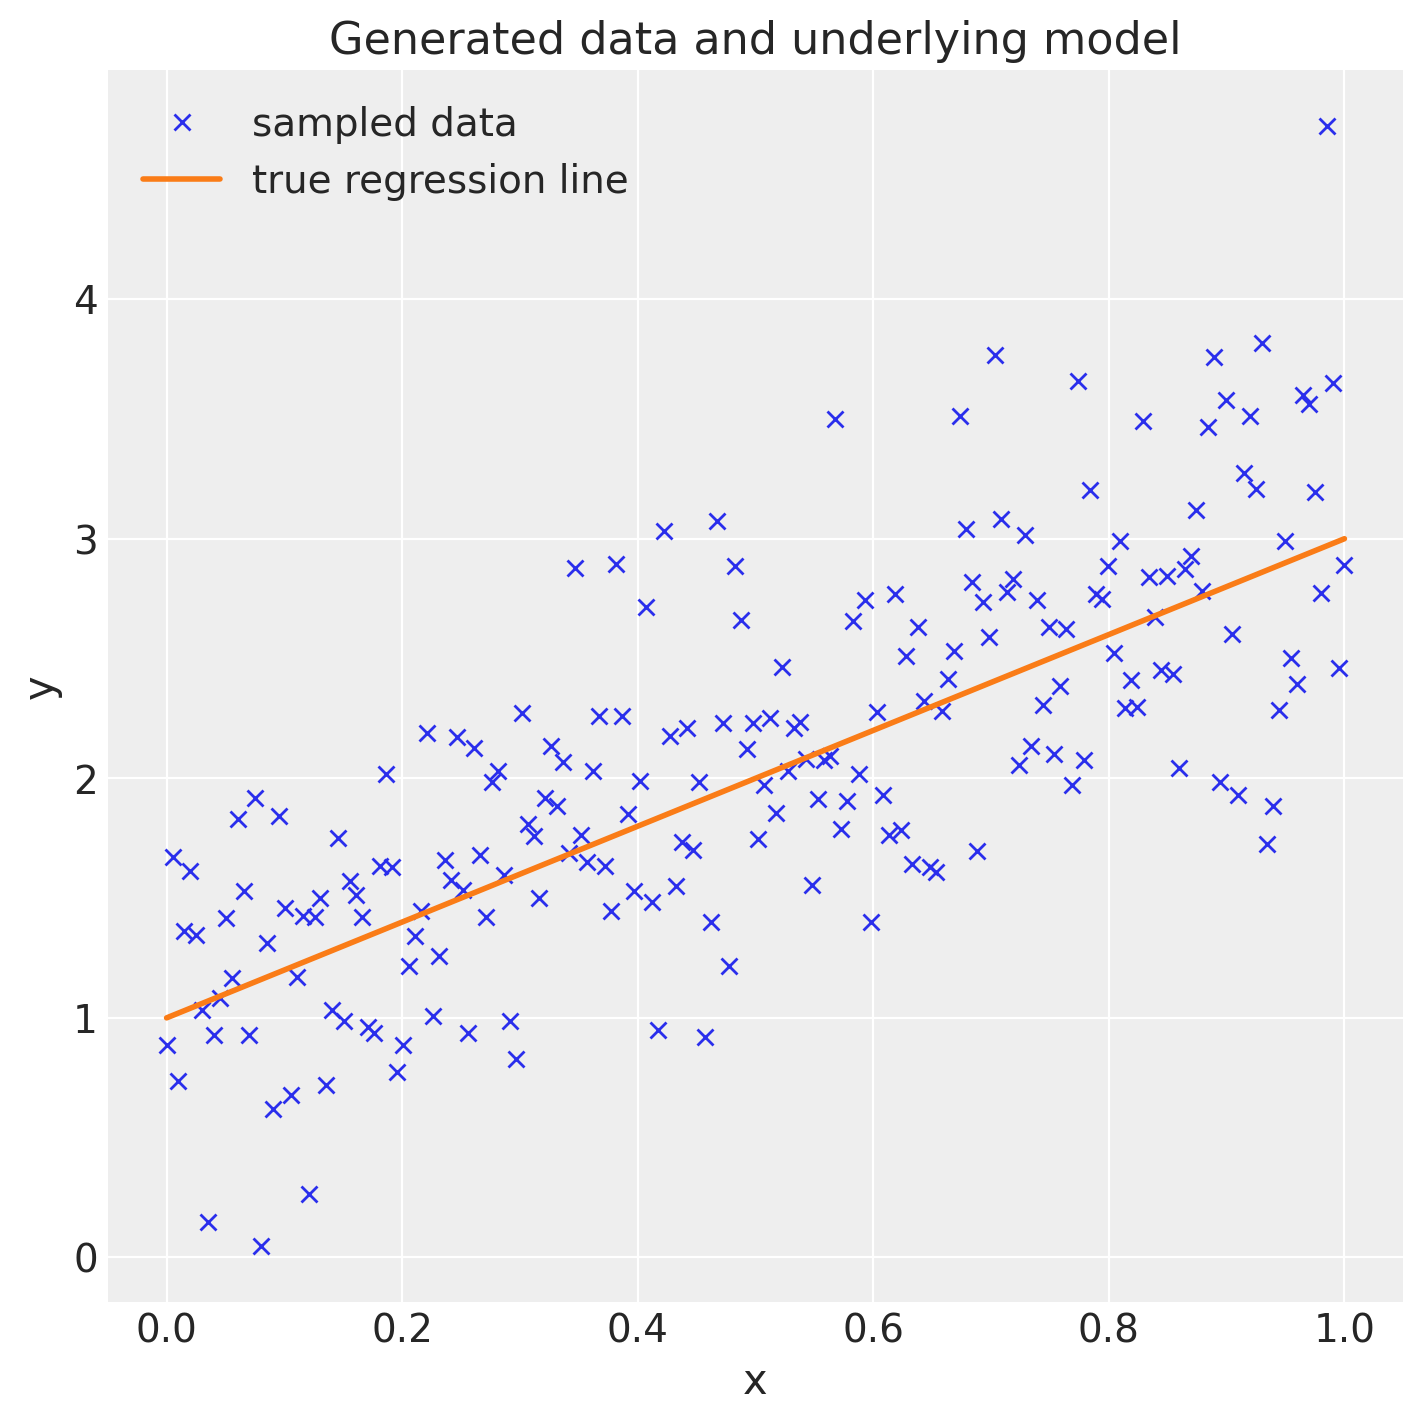

In [12]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel="x", ylabel="y", title="Generated data and underlying model")
ax.plot(x, y, "x", label="sampled data")
ax.plot(x, true_regression_line, label="true regression line", lw=2.0)
plt.legend(loc=0);

In [9]:
with Model() as model:  # model specifications in PyMC are wrapped in a with-statement
    # Define priors
    sigma = HalfCauchy("sigma", beta=10)
    intercept = Normal("Intercept", 0, sigma=20)
    slope = Normal("slope", 0, sigma=20)

    # Define likelihood
    likelihood = Normal("y", mu=intercept + slope * x, sigma=sigma, observed=y)

    # Inference!
    # draw 3000 posterior samples using NUTS sampling
    idata = sample(3000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, slope]


/Users/atlasbuchholz/PycharmProjects/UBC/STAT_405_Project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 7 seconds.


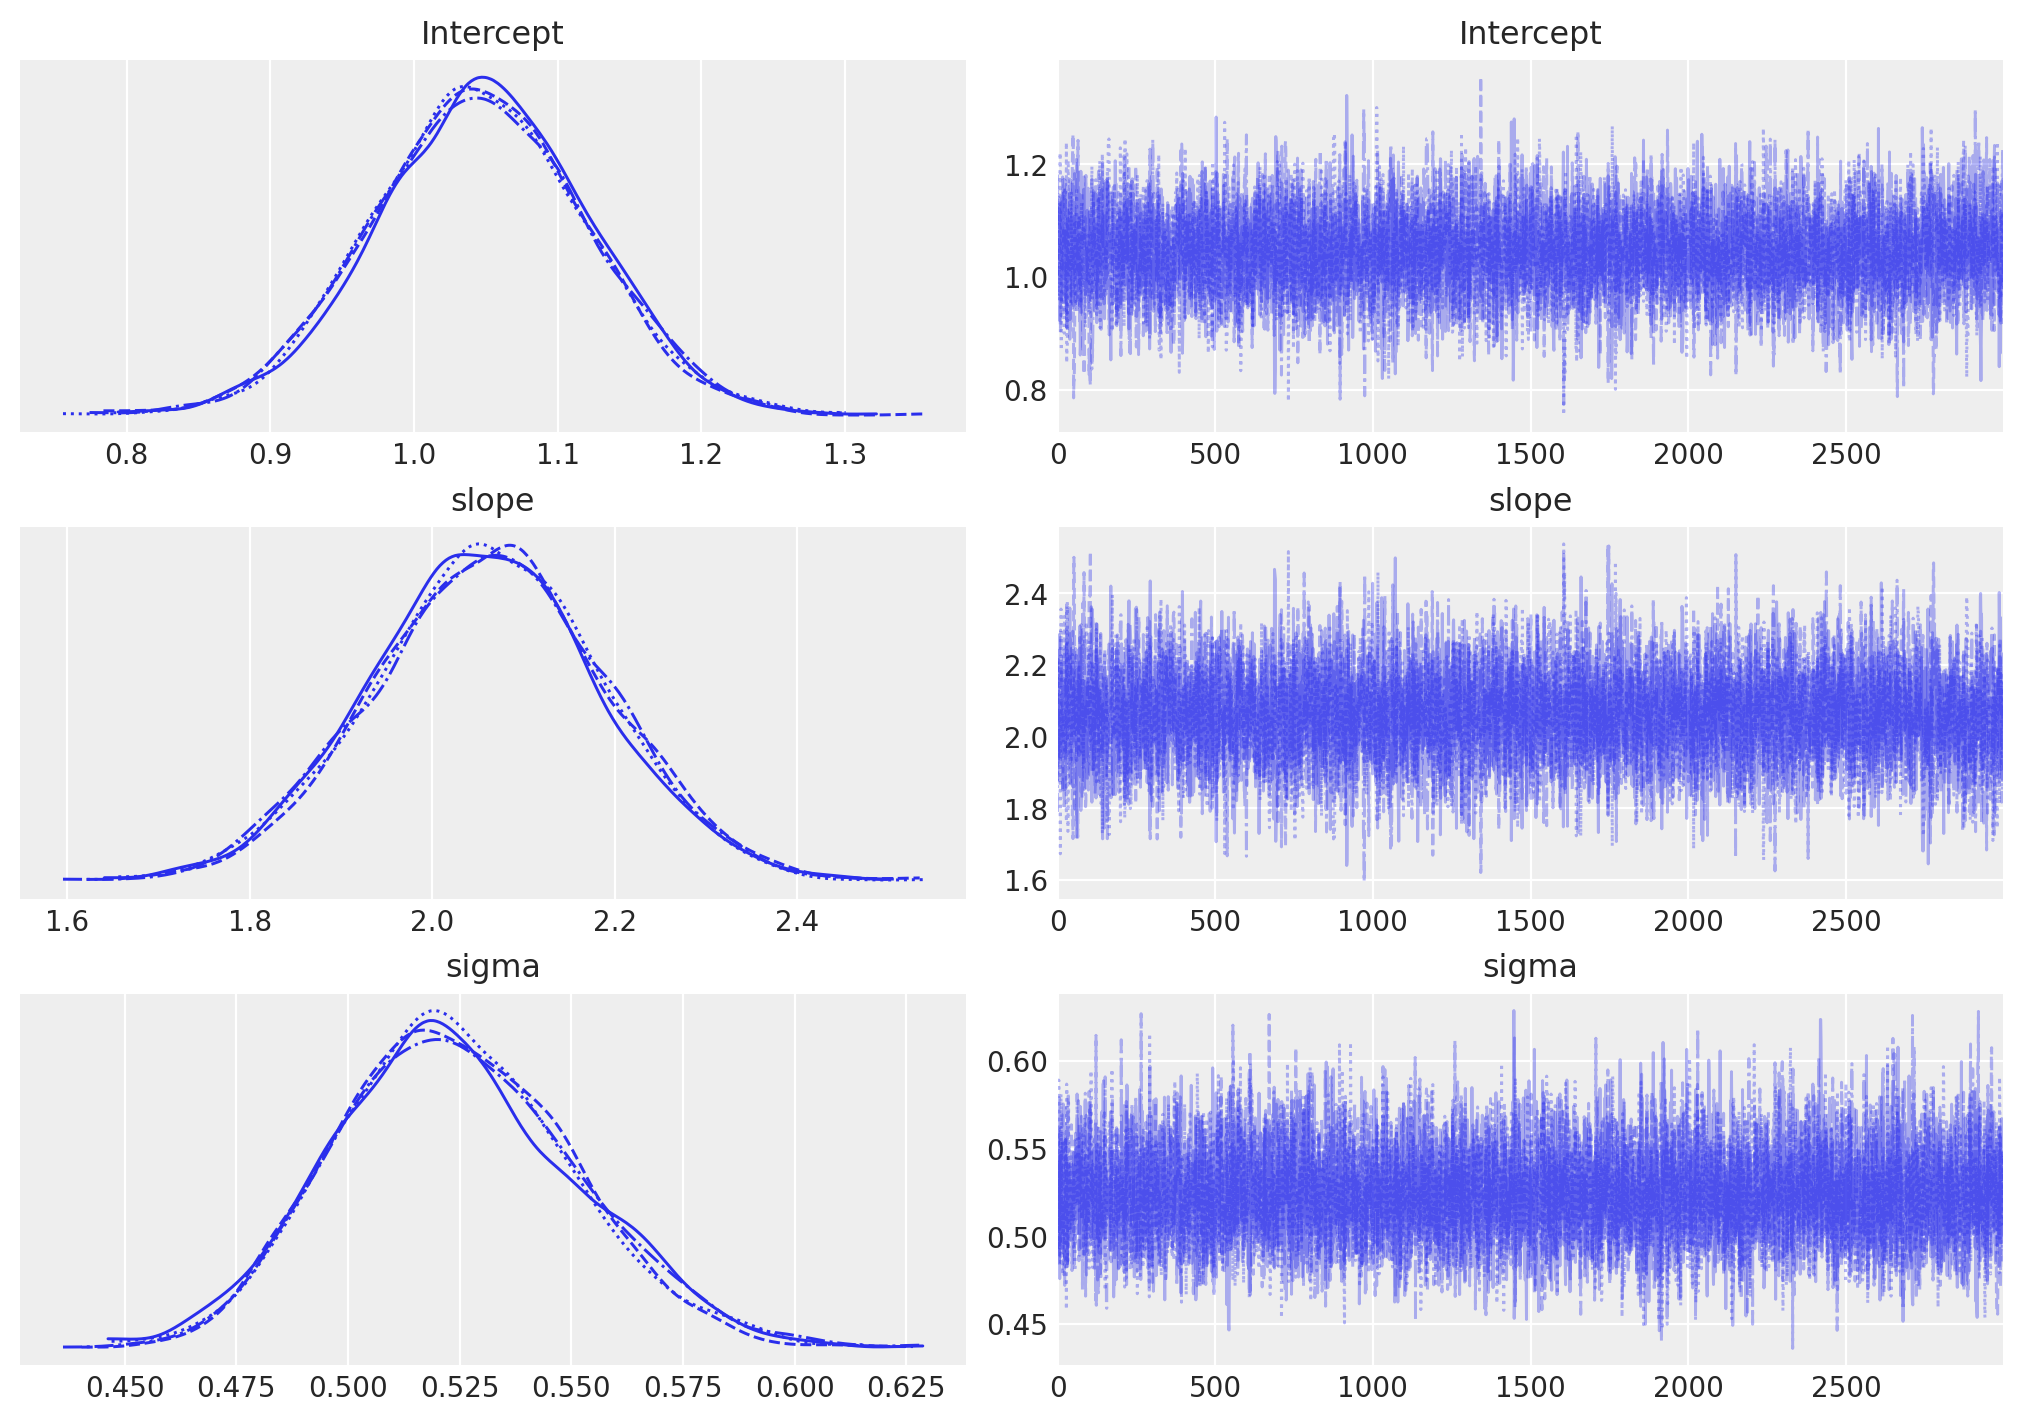

In [ ]:
az.plot_trace(idata, figsize=(10, 7));


In [ ]:
idata.posterior["y_model"] = idata.posterior["Intercept"] + idata.posterior["slope"] * xr.DataArray(x)


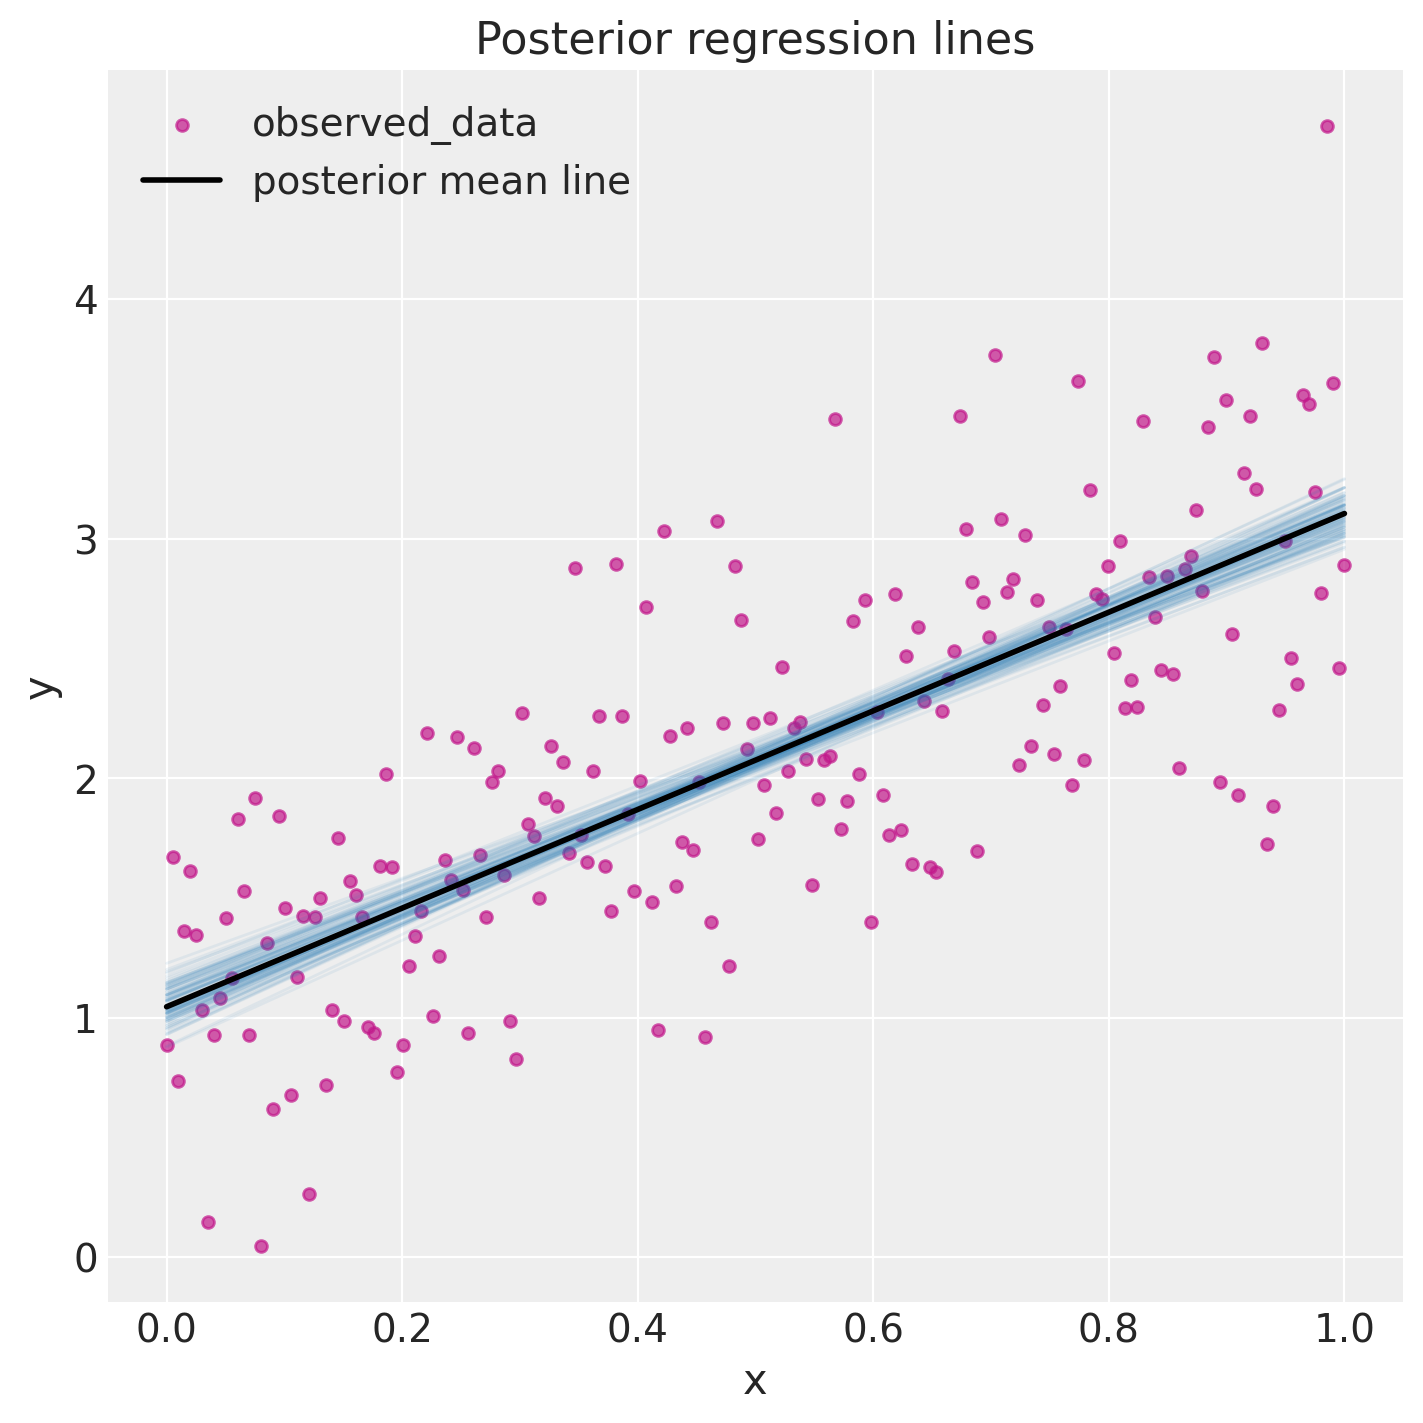

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Requires: x, y, idata, RANDOM_SEED from previous cells
_, ax = plt.subplots(figsize=(7, 7))

# observed data
ax.scatter(x, y, s=18, alpha=0.7, color="#c2188b", label="observed_data")

# flatten posterior draws
intercept_draws = idata.posterior["Intercept"].values.reshape(-1)
slope_draws = idata.posterior["slope"].values.reshape(-1)

# draw random subset of posterior lines
rng_lines = np.random.default_rng(RANDOM_SEED)
n_lines = min(100, intercept_draws.size)
line_idx = rng_lines.choice(intercept_draws.size, size=n_lines, replace=False)

for i in line_idx:
    ax.plot(
        x,
        intercept_draws[i] + slope_draws[i] * x,
        color="#1f77b4",
        alpha=0.08,
        linewidth=1,
    )

# posterior mean line
ax.plot(
    x,
    intercept_draws.mean() + slope_draws.mean() * x,
    color="black",
    linewidth=2,
    label="posterior mean line",
)

ax.set_title("Posterior regression lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="best");